*Instalação*

In [19]:
!pip install shap

Importação e Preparação dos Dados

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
import shap

warnings.filterwarnings('ignore')

dataset_path = 'mental_health_burnout_prediction_dataset.csv'
try:
    df = pd.read_csv(dataset_path)
except FileNotFoundError:
    print("Faça o upload do arquivo CSV.")

if 'df' in locals():
    df = df.drop(columns=['Person_ID', 'AI_Wellness_Recommendation'])
    df['Burnout_Risk_Binary'] = df['Burnout_Risk'].apply(lambda x: 1 if x in ['High', 'Critical'] else 0)

    X = df.drop(columns=['Burnout_Risk', 'Burnout_Score', 'Burnout_Risk_Binary'])
    y = df['Burnout_Risk_Binary']

    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X.select_dtypes(exclude=['int64', 'float64']).columns

    # Imprimindo as colunas identificadas
    print("--- IDENTIFICAÇÃO DE COLUNAS ---")
    print(f"Colunas Numéricas ({len(num_cols)}):", num_cols.tolist())
    print(f"Colunas Categóricas ({len(cat_cols)}):", cat_cols.tolist())
    print("--------------------------------\n")

    for col in num_cols:
        X[col] = X[col].fillna(X[col].median())
    for col in cat_cols:
        X[col] = X[col].fillna(X[col].mode()[0])

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    # Salvando as colunas finais para usar no SHAP
    nomes_colunas_finais = X.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Dados preparados com sucesso!")

--- IDENTIFICAÇÃO DE COLUNAS ---
Colunas Numéricas (19): ['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days']
Colunas Categóricas (17): ['Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Mental_Health_Status']
--------------------------------

Dados preparados com sucesso!


Normalização e Treinamento

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

if 'df' in locals():
    # Normalizando os dados
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Novo Modelo MLP com Dropout para evitar vício (Overfitting)
    modelo_mlp = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3), # Desativa aleatoriamente 30% dos neurônios
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2), # Desativa aleatoriamente 20% dos neurônios
        layers.Dense(1, activation='sigmoid')
    ])

    # Taxa de aprendizado explícita
    otimizador = keras.optimizers.Adam(learning_rate=0.001)

    modelo_mlp.compile(
        optimizer=otimizador,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # EarlyStopping para parar antes da época 100 se o modelo já estiver perfeito
    parada_antecipada = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print("Treinando o modelo Keras com Dropout e limite de 100 épocas...")
    historico = modelo_mlp.fit(
        X_train_scaled, y_train,
        epochs=100,           # Limite aumentado para 100
        batch_size=32,
        validation_split=0.1,
        callbacks=[parada_antecipada],
        verbose=1
    )

Treinando o modelo Keras com Dropout e limite de 100 épocas...
Epoch 1/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9510 - loss: 0.1297 - val_accuracy: 0.9875 - val_loss: 0.0500
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9844 - loss: 0.0597 - val_accuracy: 0.9877 - val_loss: 0.0466
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9856 - loss: 0.0525 - val_accuracy: 0.9877 - val_loss: 0.0470
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9857 - loss: 0.0518 - val_accuracy: 0.9877 - val_loss: 0.0468
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9859 - loss: 0.0498 - val_accuracy: 0.9877 - val_loss: 0.0474
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9859 - loss: 0.0476 - val_accuracy: 0.9877 - val_loss: 0.0459
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9859 - loss: 0.0452 - val_accuracy: 0.9877 - val_loss: 0.0471
Epoch 8/100
1125/112

Conectar Drive e Salvar

In [25]:
from google.colab import drive

# 1. Monta o Drive (vai pedir autorização do Google)
drive.mount('/content/drive')

if 'modelo_mlp' in locals():
    # 2. Salva o modelo na raiz do seu Drive com as aspas corretas!
    caminho_salvar = '/content/drive/MyDrive/model.keras'
    modelo_mlp.save(caminho_salvar)
    print(f"Modelo salvo com sucesso no Drive como '{caminho_salvar}'")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo salvo com sucesso no Drive como '/content/drive/MyDrive/model.keras'


Resultados - Curvas de Loss e Acurácia

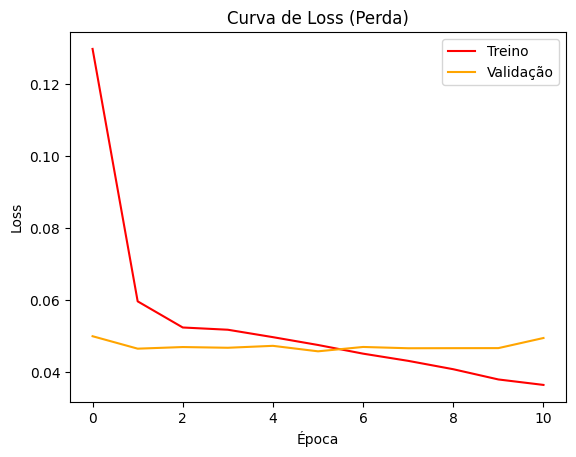

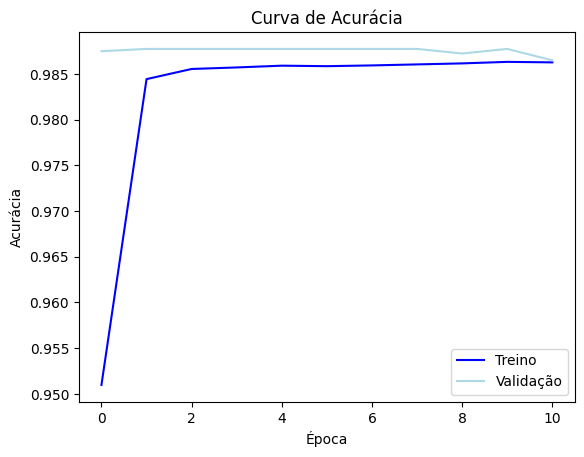

In [26]:
if 'historico' in locals():
    # Plot da Curva de Loss
    plt.figure()
    plt.plot(historico.history['loss'], color='red', label='Treino')
    plt.plot(historico.history['val_loss'], color='orange', label='Validação')
    plt.title("Curva de Loss (Perda)")
    plt.ylabel("Loss")
    plt.xlabel("Época")
    plt.legend()
    plt.show()

    # Plot da Curva de Acurácia
    plt.figure()
    plt.plot(historico.history['accuracy'], color='blue', label='Treino')
    plt.plot(historico.history['val_accuracy'], color='lightblue', label='Validação')
    plt.title("Curva de Acurácia")
    plt.ylabel("Acurácia")
    plt.xlabel("Época")
    plt.legend()
    plt.show()

Avaliação do Modelo e Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Resultados da Avaliação:
Acurácia: 0.9869
Precisão: 0.9877168015230842
Sensibilidade: 0.9869
F1-Score: 0.9870569041487359


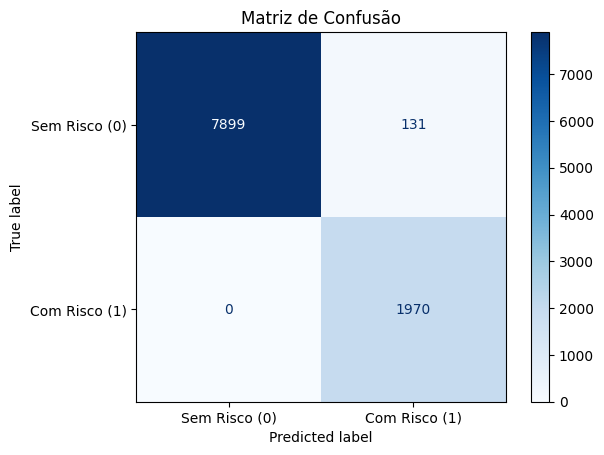

In [27]:
if 'df' in locals():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

    # O Keras retorna a probabilidade. Aqui convertemos probabilidade > 0.5 para classe 1, senão 0.
    previsoes_prob = modelo_mlp.predict(X_test_scaled)
    output_model_ = (previsoes_prob > 0.5).astype(int).flatten()

    print('\nResultados da Avaliação:')
    print('Acurácia:', accuracy_score(y_test, output_model_))
    print('Precisão:', precision_score(y_test, output_model_, average='weighted'))
    print('Sensibilidade:', recall_score(y_test, output_model_, average='weighted'))
    print('F1-Score:', f1_score(y_test, output_model_, average='weighted'))

    cm = confusion_matrix(y_test, output_model_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Risco (0)', 'Com Risco (1)'])
    disp.plot(cmap=plt.cm.Blues)
    disp.ax_.set_title('Matriz de Confusão')
    plt.show()

Gráficos SHAP

  0%|          | 0/10000 [00:00<?, ?it/s]

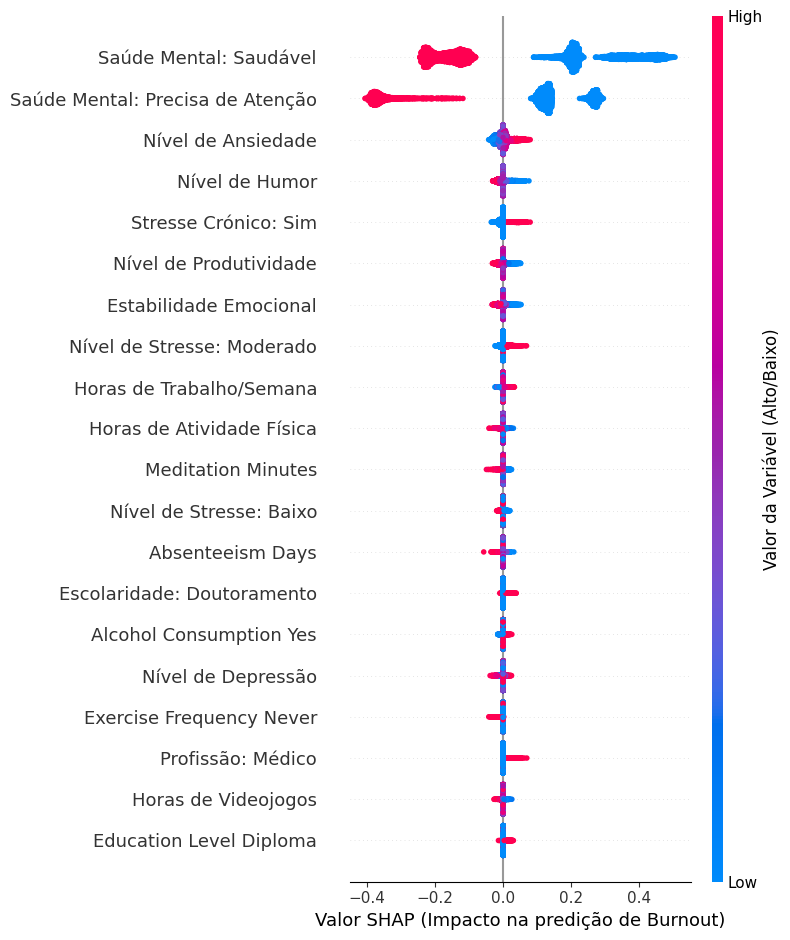

In [28]:
if 'df' in locals():
    # Função para ajudar o SHAP a ler as predições do Keras
    def pred_wrapper(x):
        return modelo_mlp.predict(x, verbose=0).flatten()

    X_train_summary = shap.kmeans(X_train_scaled, 10)
    explainer = shap.KernelExplainer(pred_wrapper, X_train_summary)
    shap_values = explainer.shap_values(X_test_scaled)

    # 1. Dicionário de tradução das variáveis do Inglês para Português
    dicionario_traducao = {
        'Mental_Health_Status_Healthy': 'Saúde Mental: Saudável',
        'Mental_Health_Status_Needs Attention': 'Saúde Mental: Precisa de Atenção',
        'Mental_Health_Status_Poor': 'Saúde Mental: Fraca',
        'Stress_Level_Moderate': 'Nível de Stresse: Moderado',
        'Stress_Level_Low': 'Nível de Stresse: Baixo',
        'Stress_Level_High': 'Nível de Stresse: Alto',
        'Chronic_Stress_Yes': 'Stresse Crónico: Sim',
        'Chronic_Stress_No': 'Stresse Crónico: Não',
        'Anxiety_Score': 'Nível de Ansiedade',
        'Mood_Score': 'Nível de Humor',
        'Productivity_Score': 'Nível de Produtividade',
        'Emotional_Stability': 'Estabilidade Emocional',
        'Depression_Score': 'Nível de Depressão',
        'Sleep_Quality_Excellent': 'Qualidade do Sono: Excelente',
        'Sleep_Quality_Good': 'Qualidade do Sono: Boa',
        'Sleep_Quality_Poor': 'Qualidade do Sono: Fraca',
        'Work_Hours_Per_Week': 'Horas de Trabalho/Semana',
        'Life_Satisfaction': 'Satisfação com a Vida',
        'Gaming_Hours': 'Horas de Videojogos',
        'Physical_Activity_Hours': 'Horas de Atividade Física',
        'Screen_Time_Hours': 'Horas de Ecrã',
        'Support_System_Excellent': 'Sistema de Apoio: Excelente',
        'Support_System_Good': 'Sistema de Apoio: Bom',
        'Support_System_Poor': 'Sistema de Apoio: Fraco',
        'Occupation_Doctor': 'Profissão: Médico',
        'Occupation_Chef': 'Profissão: Chef',
        'Occupation_Teacher': 'Profissão: Professor',
        'Occupation_Engineer': 'Profissão: Engenheiro',
        'Education_Level_PhD': 'Escolaridade: Doutoramento',
        'Education_Level_Master': 'Escolaridade: Mestrado',
        'Education_Level_Bachelor': 'Escolaridade: Licenciatura',
        'Gender_Male': 'Género: Masculino',
        'Gender_Female': 'Género: Feminino'
    }

    # 2. Traduzir os nomes da lista original (se não encontrar no dicionário, apenas retira os "underscores")
    nomes_traduzidos = [dicionario_traducao.get(nome, nome.replace('_', ' ')) for nome in nomes_colunas_finais]

    # 3. Gerar o gráfico usando os nomes em Português
    shap.summary_plot(shap_values, X_test_scaled, feature_names=nomes_traduzidos, show=False)

    fig = plt.gcf()
    if len(fig.axes) > 1:
        cax = fig.axes[-1]
        cax.set_ylabel('Valor da Variável (Alto/Baixo)', fontsize=12)

    plt.xlabel("Valor SHAP (Impacto na predição de Burnout)")
    plt.tight_layout()
    plt.show()